<h1 style="color:teal; font-size:45px; font-family:'Verdana', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook EnMAP - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Verdana', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Verdana'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 50px;">
</div>
<div style="border-left: 6px solid #2980b9; background-color: #f0f8ff; padding: 15px; margin: 20px 0; font-family:Verdana; font-size:16px;">
<h2 style="color:#2980b9; ">Sommaire</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li><a href="#00" style="color:#2c3e50; text-decoration: none;"><strong>0. Imports</strong></a></li>
    <li><a href="#10" style="color:#2c3e50; text-decoration: none;"><strong>1. Visualization</strong></a></li>
    <li><a href="#20" style="color:#2c3e50; text-decoration: none;"><strong>2. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
</ul>
</ul>
</div>
<div id="0"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    0. Imports
</h2>

In [8]:
import sys

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

from kneed import KneeLocator

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import xml.etree.ElementTree as ET

import re

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

<div id="10"></div>
<h2 style="color:#2980b9; font-size:35px; font-family:'Trebuchet MS', sans-serif; margin-top:30px; border-left: 15px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
    1. Visualization
</h2>

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We start by applying masks to the EnMAP image and display them.

In [9]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
EnMAP image with mask to only display the soil:

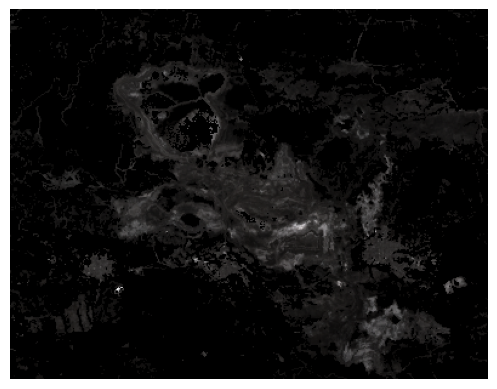

In [10]:
soil_only, fond_soil = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                       r"./INSA_cropped_2_EnMAP_20240508_mask_SOIL_SAVI_DSBI.tiff")

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
EnMAP image with mask to only display the vegetation:

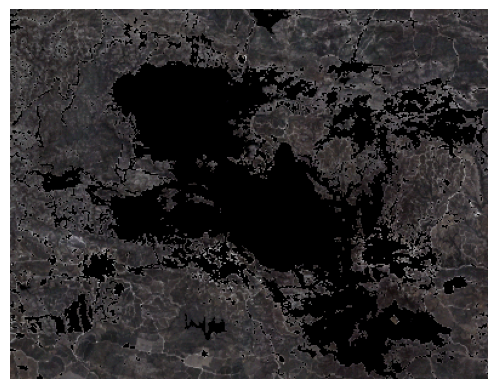

In [11]:
vegetation_only, fond_vegetation = apply_mask(r'./INSA_cropped_2_EnMAP_20240508.tif',
                             r"./INSA_cropped_2_EnMAP_20240508_mask_NDVI.tiff")

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [12]:
image_path = r'./INSA_cropped_2_EnMAP_20240508.tif'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

<div id="20"></div>
<h2 style="color:#2980b9; font-size:35px; font-family:'Trebuchet MS', sans-serif; margin-top:30px; border-left: 15px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
    2. Direct K-Means 
</h2>

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<h3 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:20px; border-left: 10px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
2.1 Vegetation
</h3>

In [13]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

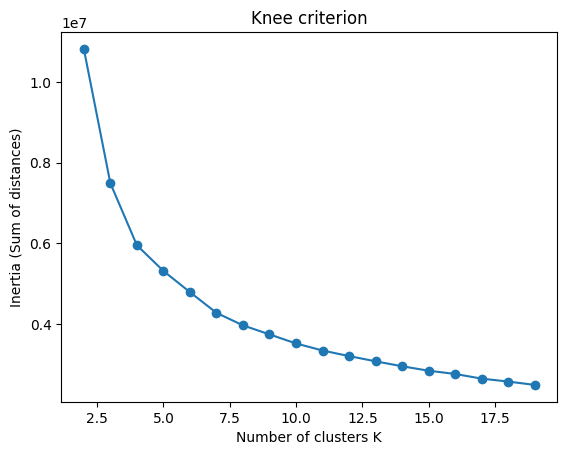

optimal value: k = 7


In [14]:
optimal_k_veg = compute_optimal_k(X_scaled_veg)

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We use the function extract_wavelengths_from_auxxml to get the number of wavelengths and their values.

In [15]:
def extract_wavelengths_from_auxxml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    wavelengths = []

    # Pour chaque bande dans l'ordre
    for band in root.findall(".//PAMRasterBand"):
        desc = band.find("Description")
        if desc is not None and desc.text:
            match = re.search(r"\(([\d.]+)\s*Nanometers\)", desc.text)
            if match:
                wl = float(match.group(1))
                wavelengths.append(wl)

    return wavelengths

In [16]:
xml_file = r"./INSA_cropped_2_EnMAP_20240508.tif.aux.xml"
wavelengths = extract_wavelengths_from_auxxml(xml_file)

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score as well as the Calinski-Harabasz Index.

In [ ]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, wavelengths, max_samples=1e4):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_scaled, labels)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    print(f"Calinski-Harabasz for k = {optimal_k} : {ch_score:.2f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = wavelengths
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 7 : 0.269
Calinski-Harabasz for k = 7 : 40269.48


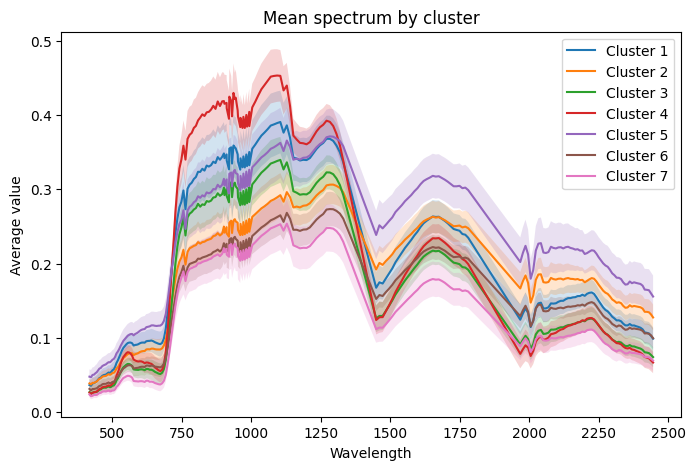

In [18]:
labels_veg = KMeans_mean_spectra(X_scaled_veg, veg_mask_1d, optimal_k_veg, l, wavelengths)

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [21]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

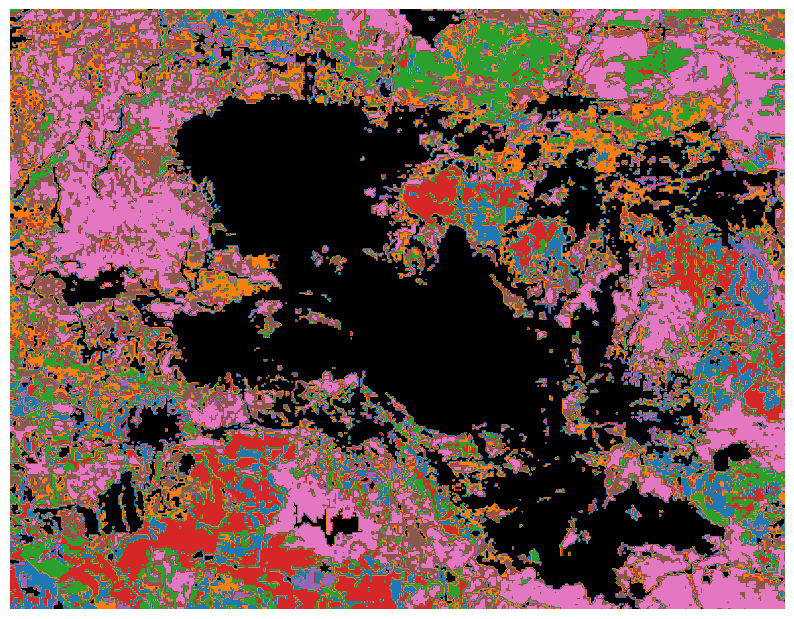

In [22]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

<div id="22"></div>
<h3 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:20px; border-left: 10px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
2.2 Soil
</h3>

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We compute the 1D and 2D masks for the soil.

In [23]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


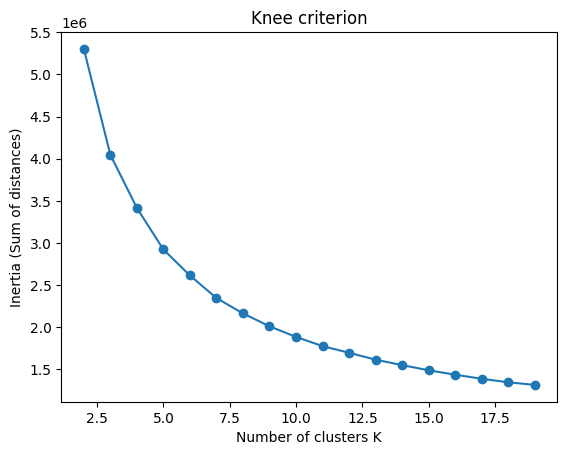

optimal value: k = 7


In [24]:
optimal_k_soil = compute_optimal_k(X_scaled_soil)

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #ff0000; background-color: #f6bcb2; padding: 10px; margin: 15px 0;">
We decide to not use the optimal k for vegetation due to external knowledge, using k = 30 instead. 

In [25]:
optimal_k_soil = 30

Silhouette (sampled) for k = 30 : 0.185
Calinski-Harabasz for k = 30 : 10426.59


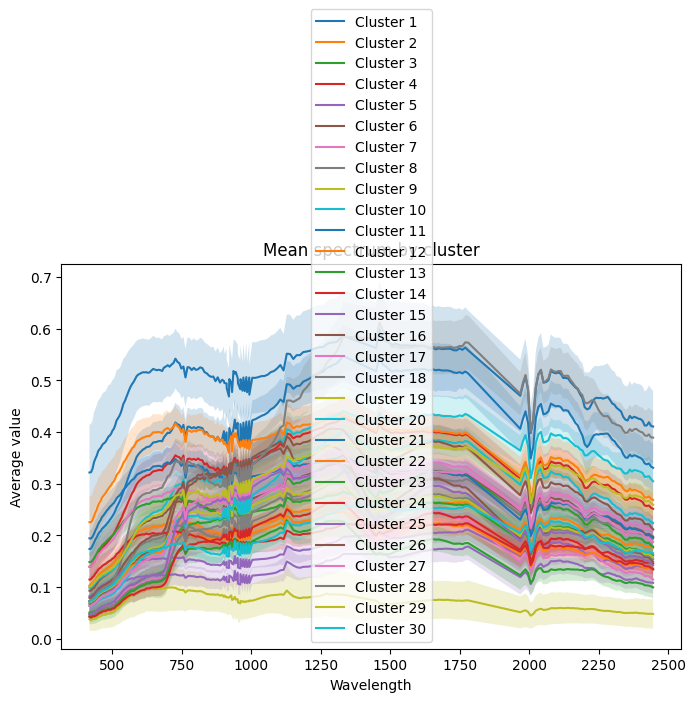

In [26]:
labels_soil = KMeans_mean_spectra(X_scaled_soil, soil_mask_1d, optimal_k_soil, l, wavelengths)

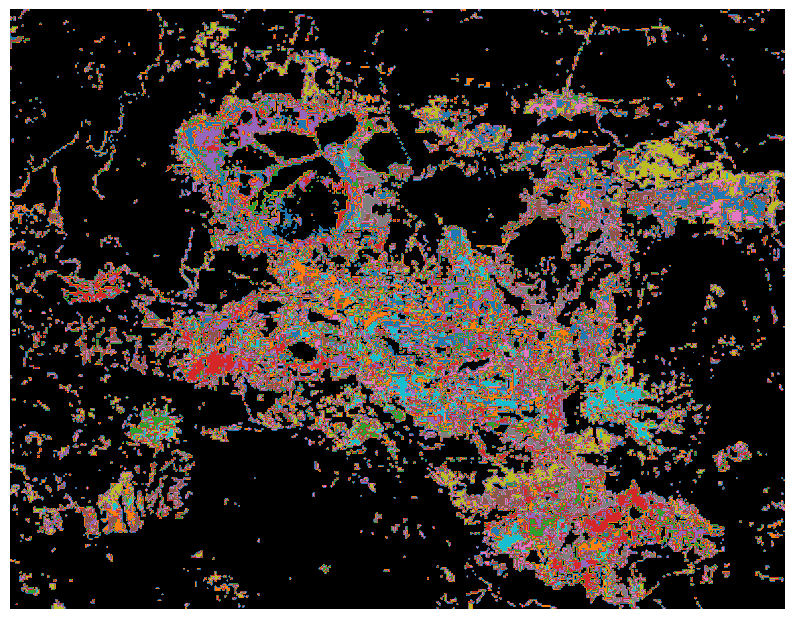

In [27]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<h3 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:20px; border-left: 10px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
2.3 Other
</h3>

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We compute the 1D and 2D masks for the rest.

In [28]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

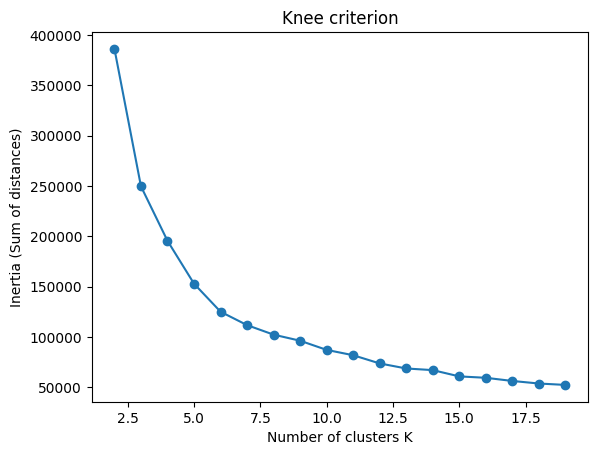

optimal value: k = 6


In [29]:
optimal_k_other = compute_optimal_k(X_scaled_other)

Silhouette (sampled) for k = 6 : 0.481
Calinski-Harabasz for k = 6 : 9139.13


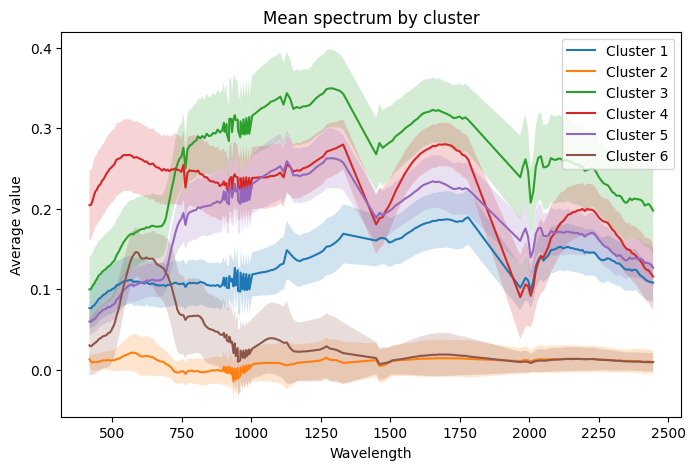

In [30]:
labels_other = KMeans_mean_spectra(X_scaled_other, other_mask_1d, optimal_k_other, l, wavelengths)

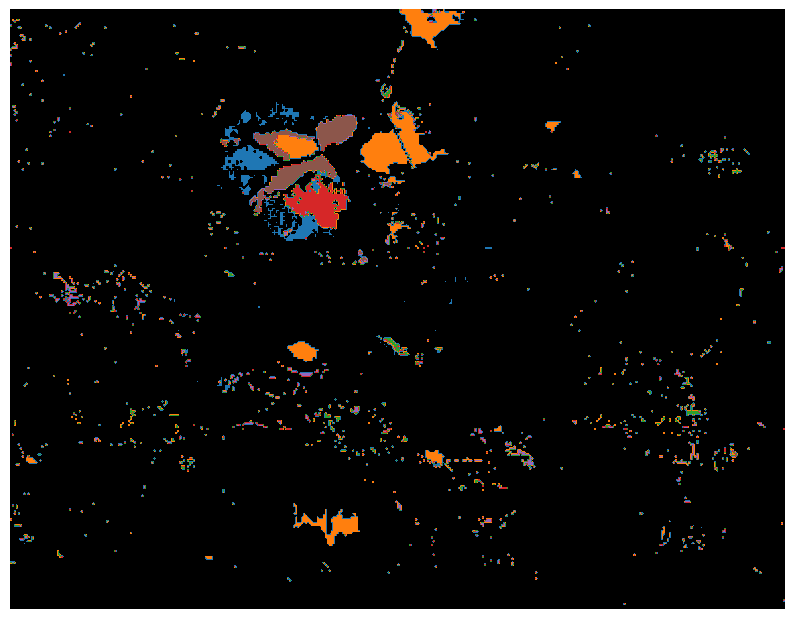

In [31]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<h2 style="color:#2980b9; font-size:35px; font-family:'Trebuchet MS', sans-serif; margin-top:30px; border-left: 15px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
    3. Pixel-by-Pixel AutoEncoder K-Means 
</h2>

<p style="font-size:16px; font-family:'Verdana', sans-serif; color:#2d3436; line-height:1.6; border-left: 5px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [50]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(256, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(256, 512),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(512, in_dim),
            nn.Sigmoid() # Pour s'assurer que les pixels sont entre 0 et 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [42]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [46]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples=10000):

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    n_samples = X_scaled.shape[0]

    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels_1d[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels_1d

    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_sampled, labels_sampled)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")
    print(f"Calinski-Harabasz pour k = {n_clusters} : {ch_score:.2f}")

In [36]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<h3 style="color:#2980b9; font-size:28px; font-family:'Trebuchet MS', sans-serif; margin-top:20px; border-left: 10px solid #3498db; background-color: #ecf5fb; padding: 10px; margin: 15px 0;">
3.1 Vegetation
</h3>

In [51]:
train_PbP_autoencoder(16, 5, X_scaled_veg, optimal_k_veg)

Epoch 1/5   Loss = 0.580275
Epoch 2/5   Loss = 0.544314
Epoch 3/5   Loss = 0.543510
Epoch 4/5   Loss = 0.542577
Epoch 5/5   Loss = 0.540378
Silhouette (échantillon) pour k = 7 : 0.239
Calinski-Harabasz pour k = 7 : 4686.78


In [ ]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_soil = torch.tensor(X_scaled_soil, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_soil.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_soil.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_soil = X_scaled_soil[idx]
    labels_sampled_soil = labels_1d_soil[idx]
else:
    X_sampled_soil = X_scaled_soil
    labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(X_sampled_soil, labels_sampled_soil)
ch_score  = calinski_harabasz_score(X_sampled_soil, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.680767
Epoch 2/5   Loss = 0.593620
Epoch 3/5   Loss = 0.587706
Epoch 4/5   Loss = 0.582763
Epoch 5/5   Loss = 0.580698
Silhouette (échantillon) pour k = 30 : 0.148
Calinski-Harabasz pour k = 30 : 2307.38


In [ ]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_other = torch.tensor(X_scaled_other, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_other.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 6
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 10000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_other.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_other = X_scaled_other[idx]
    labels_sampled_other = labels_1d_other[idx]
else:
    X_sampled_other = X_scaled_other
    labels_sampled_other = labels_1d_other

sil_score = silhouette_score(X_sampled_other, labels_sampled_other)
ch_score  = calinski_harabasz_score(X_sampled_other, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.944461
Epoch 2/5   Loss = 0.617777
Epoch 3/5   Loss = 0.587017
Epoch 4/5   Loss = 0.571538
Epoch 5/5   Loss = 0.565590
Silhouette (échantillon) pour k = 6 : 0.429
Calinski-Harabasz pour k = 6 : 7875.19


In [ ]:
"""
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, input_size=128):
    
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, 2, 1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, 2, 1),          # H/8
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, 2, 1),         # H/16
            nn.ReLU(True),
        )

        # Calculer la taille du tenseur après convolutions
        conv_out_size = 256 * (input_size // 16) * (input_size // 16)

        # ------- LATENT VECTOR -------
        self.fc_enc = nn.Linear(conv_out_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, conv_out_size)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),    # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3, 2, 1, 1),  # H*2
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        batch_size = z.size(0)
        z = z.view(batch_size, -1)        # Flatten
        z = self.fc_enc(z)                # Latent vector

        # Decoder
        z = self.fc_dec(z)
        z = z.view(batch_size, 256, x.size(2)//16, x.size(3)//16)  # reshape pour decoder
        x_recon = self.decoder_conv(z)
        return x_recon
"""

'\nclass ConvAutoencoder(nn.Module):\n    def __init__(self, in_channels=3, latent_dim=128, input_size=128):\n\n        super(ConvAutoencoder, self).__init__()\n\n        # ------- ENCODER -------\n        self.encoder_conv = nn.Sequential(\n            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2\n            nn.ReLU(True),\n\n            nn.Conv2d(32, 64, 3, 2, 1),           # H/4\n            nn.ReLU(True),\n\n            nn.Conv2d(64, 128, 3, 2, 1),          # H/8\n            nn.ReLU(True),\n\n            nn.Conv2d(128, 256, 3, 2, 1),         # H/16\n            nn.ReLU(True),\n        )\n\n        # Calculer la taille du tenseur après convolutions\n        conv_out_size = 256 * (input_size // 16) * (input_size // 16)\n\n        # ------- LATENT VECTOR -------\n        self.fc_enc = nn.Linear(conv_out_size, latent_dim)\n        self.fc_dec = nn.Linear(latent_dim, conv_out_size)\n\n        # ------- DECODER -------\n        self.decoder_conv = nn.Sequential(\n            nn.ConvTran

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=1, padding=1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),          # H/8
            nn.ReLU(True)
        )
        
        # Pas besoin de input_size fixe : taille après conv dépend du patch
        self.fc_enc = None  # on initialisera dynamiquement au premier forward
        self.fc_dec = None

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride= 1, padding=1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3,stride= 1, padding=1),    # H*2
            nn.Sigmoid()
        )

        self.latent_dim = latent_dim
        self._fc_initialized = False

    def _init_fc(self, x):
        # Calculer la taille de flatten après encoder pour ce patch
        with torch.no_grad():
            z = self.encoder_conv(x)
            batch_size, c, h, w = z.size()
            
            # --- CORRECTION ICI ---
            # On crée la couche ET on l'envoie immédiatement sur le device de x (le GPU)
            self.fc_enc = nn.Linear(c*h*w, self.latent_dim).to(x.device)
            self.fc_dec = nn.Linear(self.latent_dim, c*h*w).to(x.device)
            # ----------------------
            
        self._fc_initialized = True

    def forward(self, x):
        if not self._fc_initialized:
            self._init_fc(x)
        # Encoder
        z = self.encoder_conv(x)
        batch_size, c, h, w = z.size()
        z_flat = z.view(batch_size, -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(batch_size, c, h, w)  # reshape exactement aux dimensions du conv
        x_recon = self.decoder_conv(z_dec)
        return x_recon, z_latent
    def encode(self, x):
        latent_map = self.encoder_conv(x)
        latent = latent_map.view(latent_map.size(0), -1)
        return latent

In [ ]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [ ]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

### VEGETATION

In [ ]:
if __name__ == "__main__":
    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    # IMPORTANT : Assurez-vous que le modèle est envoyé sur le device ICI
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # ----------------------------------------------------------
    # Préparer les patchs glissants
    # ----------------------------------------------------------
    #PATCH_SIZE = 4
    STRIDE = 2
    BATCH_SIZE = 128
    #LATENT_DIM = 8
    #EPOCHS = 5
    #DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #N_CLUSTERS = 5
    def extract_valid_patches_with_mask(image, mask, patch_size=16, stride=8, min_fraction=1.0):
        """
        Extrait des patchs valides selon un masque.
        
        image : [C,H,W]
        mask  : [H,W] ou [1,H,W], bool ou 0/1
        """
        if mask.dim() == 3:
            mask = mask[0]  # si mask [1,H,W]
        
        C, H, W = image.shape
        patches = []
        positions = []
    
        for i in range(0, H-patch_size+1, stride):
            for j in range(0, W-patch_size+1, stride):
                patch_mask = mask[i:i+patch_size, j:j+patch_size]
                valid_fraction = patch_mask.float().mean().item()
                if valid_fraction >= min_fraction:
                    patch = image[:, i:i+patch_size, j:j+patch_size]
                    patches.append(patch.unsqueeze(0))
                    positions.append((i,j))
        
        if len(patches) > 0:
            patch_tensor = torch.cat(patches, dim=0)
        else:
            patch_tensor = torch.empty(0, C, patch_size, patch_size)
        
        return patch_tensor, positions
    
    
    # ----------------------------------------------------------
    # Exemple : image hyperspectrale
    # img_scaled_veg_complete : [C,H,W]
    # ----------------------------------------------------------
    C, H, W = l,m,n
    patch_tensor, positions = extract_valid_patches_with_mask(torch.Tensor(img_scaled_veg_complete.T.reshape(l,m,n)), torch.Tensor(veg_mask_2d), PATCH_SIZE, STRIDE)
    print(f"Nombre de patchs valides : {len(patch_tensor)}")
    

    # --- Dataset ---
    #X_tensor_veg = torch.tensor(patch_tensor, dtype=torch.float32)
    dataset = TensorDataset(patch_tensor)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Paramètres boucle
    total_idx = []
    n_batches = 10
    all_latents = []

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

        # Échantillonnage aléatoire
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        subset_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        for batch in loader:
            x = batch[0].to(DEVICE)
            optimizer.zero_grad()
            out, _ = model(x)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{len(subset_loader)}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        
        print(f"\nEpoch {ep+1}/{EPOCHS}   Moyenne Loss = {loss_sum/len(subset_loader):.6f}")

Utilization du device : cuda
Nombre de patchs valides : 2076
Epoch 1/5  Batch 1/17  Loss: 0.937017
Epoch 1/5   Moyenne Loss = 1.091921
Epoch 2/5  Batch 1/17  Loss: 0.919708
Epoch 2/5   Moyenne Loss = 0.954286
Epoch 3/5  Batch 1/17  Loss: 0.826387
Epoch 3/5   Moyenne Loss = 0.892932
Epoch 4/5  Batch 1/17  Loss: 0.797111
Epoch 4/5   Moyenne Loss = 0.813524
Epoch 5/5  Batch 1/17  Loss: 0.834120
Epoch 5/5   Moyenne Loss = 0.806810


In [ ]:
# ----------------------
# Extraction des latents
# ----------------------
model.eval()
all_latents = []
with torch.no_grad():
    for batch in DataLoader(patch_tensor, batch_size=BATCH_SIZE, shuffle=False):
        x = batch[0].to(DEVICE)
        latent = model.encode(x)
        all_latents.append(latent.cpu().numpy())
latent_vectors = np.concatenate(all_latents, axis=0)

In [ ]:
# ------------------------------------------------------------------
# K-means
# ------------------------------------------------------------------
idx = np.random.choice(dataset_size, n_samples, replace=False)


n_clusters_veg = 7
kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
print(latent_vectors.shape)
labels_1d_veg = kmeans.fit_predict(latent_vectors)

#classification_map = labels_1d_veg.reshape(H, W)

X_sampled_veg = X_tensor_veg[total_idx]
labels_sampled_veg = labels_1d_veg

subset_X_sampled_veg = Subset(X_sampled_veg, idx)

sil_score = silhouette_score(latent_vectors, labels_sampled_veg)
print(f"Silhouette (échantillon) pour k = {n_clusters_veg} : {sil_score:.3f}")
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_veg)
print(f"Calinski-Harabasz pour k = {n_clusters_veg} : {ch_score:.2f}")

(2176, 256)
Silhouette (échantillon) pour k = 7 : 0.500
Calinski-Harabasz pour k = 7 : 1940.39


### SOL

In [ ]:
print(img_scaled_soil_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_soil = torch.tensor(img_scaled_soil_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_soil.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

X_sampled_soil = X_tensor_soil[total_idx]
labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(latent_vectors, labels_sampled_soil)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

(120170, 219)
Epoch 1/5  Batch 10/10  Loss: 0.397297Epoch 1/5   Loss = 0.544306
Epoch 2/5  Batch 10/10  Loss: 0.345642Epoch 2/5   Loss = 0.354314
Epoch 3/5  Batch 10/10  Loss: 0.316823Epoch 3/5   Loss = 0.340470
Epoch 4/5  Batch 10/10  Loss: 0.464851Epoch 4/5   Loss = 0.332527
Epoch 5/5  Batch 10/10  Loss: 0.411462Epoch 5/5   Loss = 0.345578
Silhouette (échantillon) pour k = 30 : 0.375
Calinski-Harabasz pour k = 30 : 949.61


In [ ]:
print(img_scaled_other_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 10               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_other = torch.tensor(img_scaled_other_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_other.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 6
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

labels_sampled_other = labels_1d_other

sil_score = silhouette_score(latent_vectors, labels_sampled_other)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

(120170, 219)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [ ]:
print(X_sampled_veg.shape)
print(labels_sampled_veg.shape)
print(len(total_idx))
print(latent_vectors.shape)

torch.Size([6400, 219])
(6400,)
6400
(6400, 128)


Nombre de clusters pour la végétation avec CAH

In [ ]:


N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')


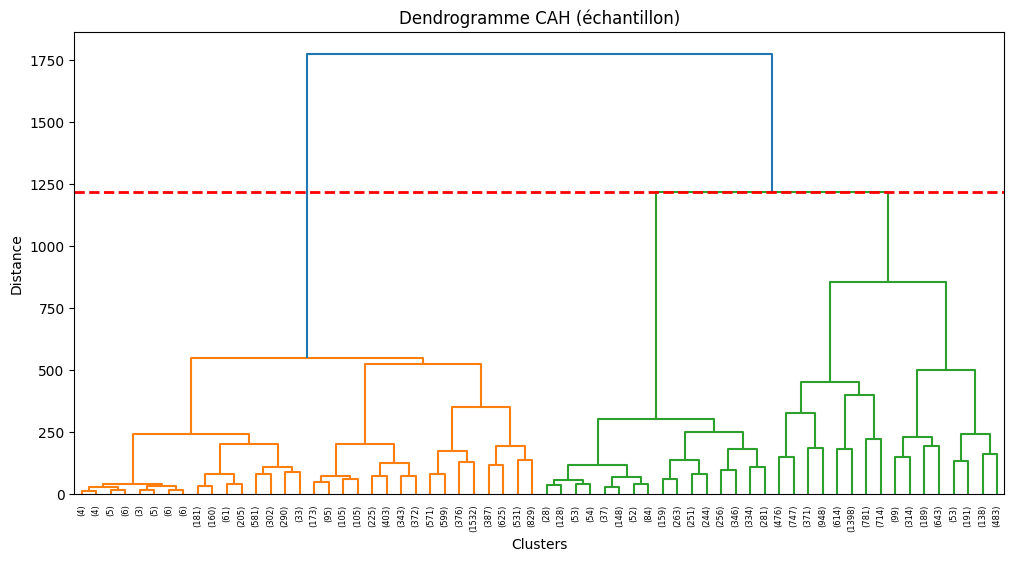

In [ ]:


plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

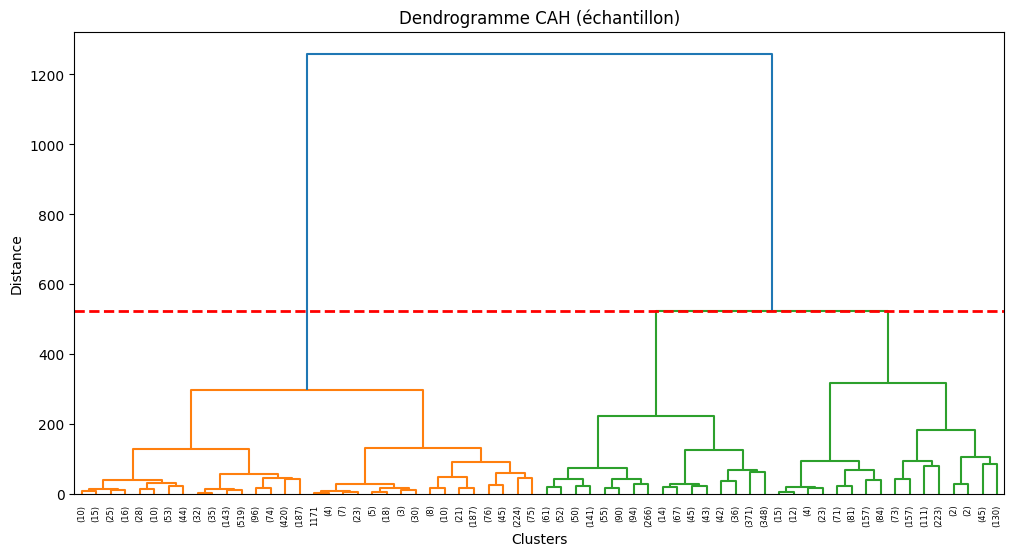

In [ ]:
X_sample = X_scaled_other

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


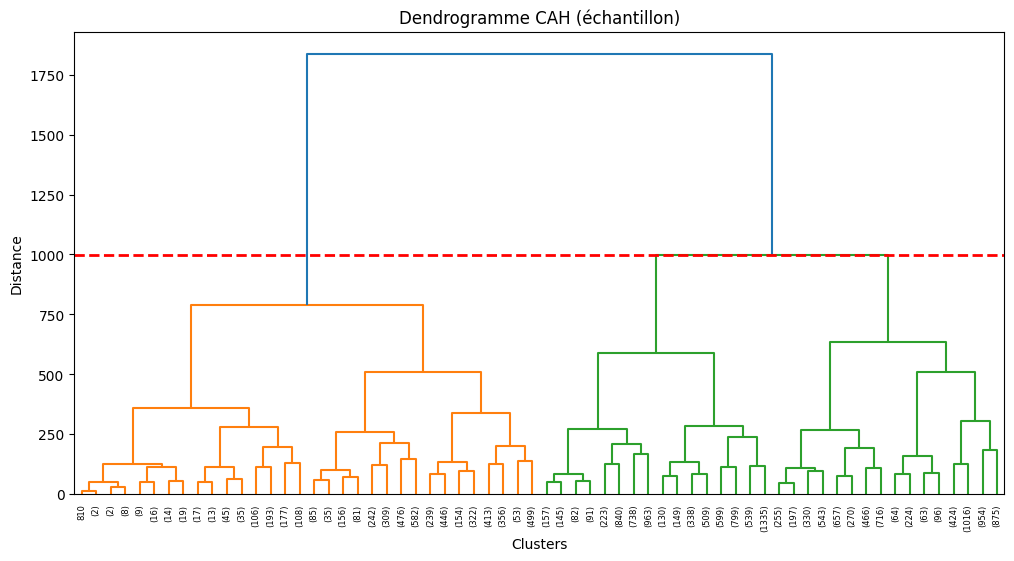

In [ ]:
N = 20000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()